
# AI-Based Predictive Maintenance System for Bearing Fault Diagnosis

### Dataset
Case Western Reserve University (CWRU) Bearing Dataset

### Objective
Detect bearing faults (Normal, Ball, Inner Race, Outer Race) using vibration signal analysis and Machine Learning.


## 1. Import Libraries

In [1]:

import os
import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.stats import kurtosis, skew, entropy

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

plt.rcParams['figure.figsize']=(10,5)


## 2. Dataset Path

In [9]:

dataset_path='sample'
window_size=2048


In [11]:
import os
# remove macOS junk files
for root, dirs, filenames in os.walk(dataset_path):
    for f in filenames:
        if f == '.DS_Store':
            os.remove(os.path.join(root, f))

print("Cleaned. Remaining items:", os.listdir(dataset_path))
sample_class = os.listdir(dataset_path)[0]

print("Found classes:", os.listdir(dataset_path))

class_path = os.path.join(dataset_path, sample_class)
sample_file = os.path.join(class_path, os.listdir(class_path)[0])
print("Testing file:", sample_file)

from scipy.io import loadmat
data = loadmat(sample_file)
print("Keys in file:", data.keys())

Cleaned. Remaining items: ['normal', 'inner race', 'outer race', 'ball fault']
Found classes: ['normal', 'inner race', 'outer race', 'ball fault']
Testing file: sample/normal/Time_Normal_1_098.mat
Keys in file: dict_keys(['__header__', '__version__', '__globals__', 'X098_DE_time', 'X098_FE_time'])


## 3. Helper Functions

In [13]:

def get_signal(mat_file):

    data = loadmat(mat_file)

    for key in data.keys():
        if 'DE_time' in key:
            return data[key].flatten()

    return None


def spectral_entropy(signal):

    fft_mag=np.abs(np.fft.rfft(signal))
    prob=fft_mag/np.sum(fft_mag)

    return entropy(prob)


def extract_features(signal):

    rms=np.sqrt(np.mean(signal**2))

    mean=np.mean(signal)

    std=np.std(signal)

    variance=np.var(signal)

    peak=np.max(np.abs(signal))

    p2p=np.ptp(signal)

    kurt=kurtosis(signal)

    skw=skew(signal)

    crest=peak/(rms+1e-10)

    fft_mag=np.abs(np.fft.rfft(signal))

    fft_mean=np.mean(fft_mag)

    fft_std=np.std(fft_mag)

    fft_max=np.max(fft_mag)

    dom_freq=np.argmax(fft_mag)

    energy=np.sum(signal**2)

    spec_entropy=spectral_entropy(signal)

    return [
        rms,mean,std,variance,peak,p2p,
        kurt,skw,crest,
        fft_mean,fft_std,fft_max,
        dom_freq,energy,spec_entropy
    ]


## 4. Visualize Sample Signal

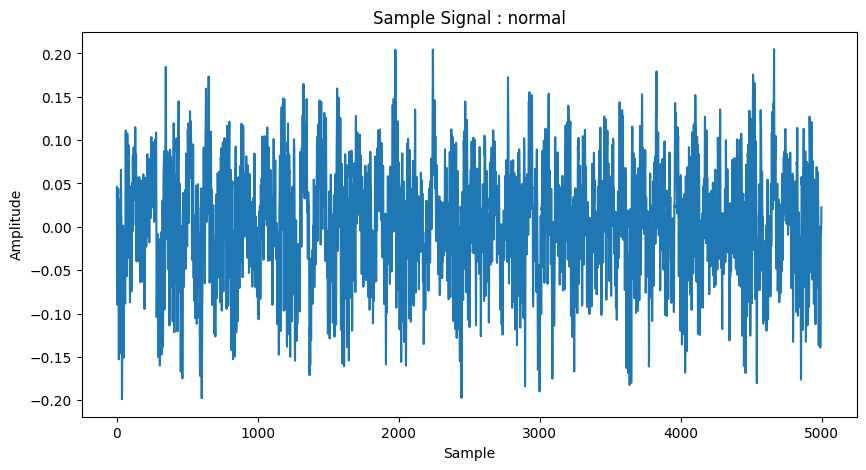

In [14]:

sample_class=os.listdir(dataset_path)[0]

sample_file=os.path.join(
    dataset_path,
    sample_class,
    os.listdir(os.path.join(dataset_path,sample_class))[0]
)

signal=get_signal(sample_file)

plt.plot(signal[:5000])
plt.title(f'Sample Signal : {sample_class}')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()


## 5. FFT Analysis

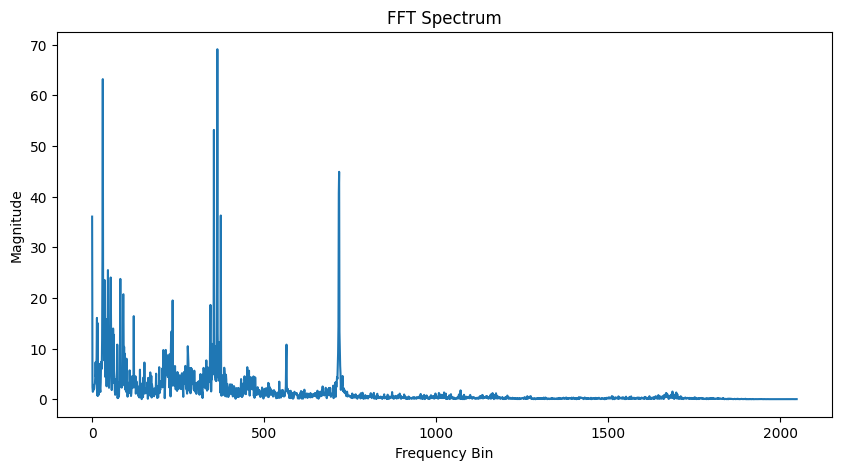

In [15]:

fft=np.abs(np.fft.rfft(signal[:4096]))

plt.plot(fft)
plt.title('FFT Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Magnitude')
plt.show()


## 6. Create Feature Dataset

In [16]:

X=[]
y=[]

for label in os.listdir(dataset_path):

    class_path=os.path.join(dataset_path,label)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):

        if file.endswith('.mat'):

            sig=get_signal(
                os.path.join(class_path,file)
            )

            if sig is None:
                continue

            for i in range(
                0,
                len(sig)-window_size,
                window_size
            ):

                seg=sig[i:i+window_size]

                X.append(
                    extract_features(seg)
                )

                y.append(label)

print("Total samples:",len(X))


Total samples: 2369


## 7. DataFrame

In [17]:

features=[
'RMS','Mean','STD','Variance',
'Peak','PeakToPeak',
'Kurtosis','Skewness',
'CrestFactor',
'FFT_Mean','FFT_STD',
'FFT_Max','DominantFreq',
'Energy','SpectralEntropy'
]

df=pd.DataFrame(X,columns=features)

df['Fault']=y

df.head()


,RMS,Mean,STD,Variance,Peak,PeakToPeak,Kurtosis,Skewness,CrestFactor,FFT_Mean,FFT_STD,FFT_Max,DominantFreq,Energy,SpectralEntropy,Fault
0,0.066925,0.008002,0.066445,0.004415,0.204234,0.403045,-0.180225,-0.277955,3.051702,1.118894,2.836014,40.187853,182,9.172841,5.728990,normal
1,0.063714,0.009596,0.062987,0.003967,0.204443,0.401793,-0.016090,-0.272366,3.208751,1.099183,2.699249,34.224900,182,8.313862,5.769125,normal
2,0.063972,0.010816,0.063052,0.003975,0.211327,0.391571,-0.193607,-0.210519,3.303413,1.087224,2.725893,35.612890,177,8.381383,5.745025,normal
3,0.065280,0.011418,0.064273,0.004131,0.200897,0.397621,0.106033,-0.096584,3.077483,1.095059,2.790423,36.359352,15,8.727381,5.737327,normal
4,0.064787,0.012309,0.063607,0.004046,0.227808,0.439344,-0.031916,-0.225658,3.516268,1.092529,2.775636,35.445644,182,8.596147,5.722125,normal


In [18]:
print(df['Fault'].value_counts())

Fault
inner race    711
outer race    711
ball fault    711
normal        236
Name: count, dtype: int64


## 8. Class Distribution

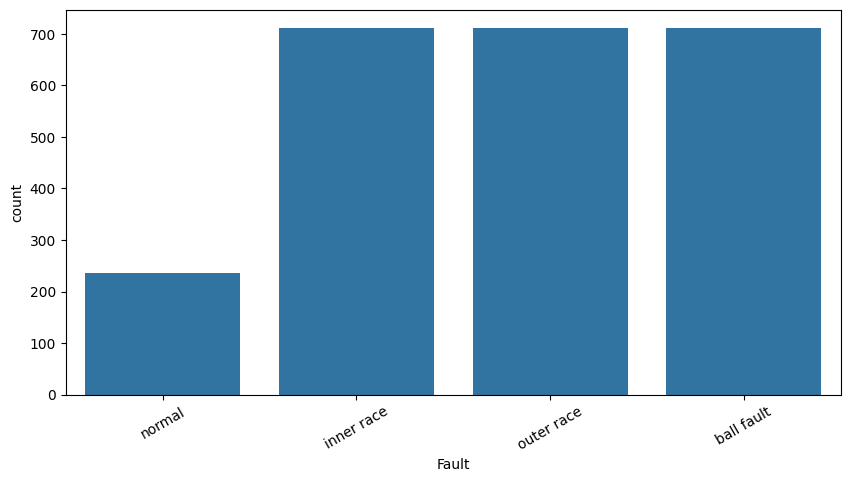

In [19]:

sns.countplot(data=df,x='Fault')
plt.xticks(rotation=30)
plt.show()


## 9. Statistical Summary

In [20]:

df.describe()


,RMS,Mean,STD,Variance,Peak,PeakToPeak,Kurtosis,Skewness,CrestFactor,FFT_Mean,FFT_STD,FFT_Max,DominantFreq,Energy,SpectralEntropy
count,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000
mean,0.342804,0.015706,0.342033,0.210358,1.626806,3.134479,2.688384,-0.042703,4.307420,4.426918,14.861608,180.350944,115.185732,431.404415,5.267186
std,0.305240,0.006467,0.305633,0.342762,1.630800,3.185056,4.450196,0.182512,1.210786,3.273489,13.434054,187.201605,44.634695,701.853549,0.339316
min,0.061067,0.003245,0.059126,0.003496,0.175863,0.342546,-0.801650,-1.090735,2.469191,1.032312,2.584190,29.679025,0.000000,7.637272,4.531836
25%,0.136505,0.011238,0.135552,0.018374,0.467298,0.884112,-0.012628,-0.104093,3.347146,1.854434,5.923264,61.372769,110.000000,38.161819,5.037695
50%,0.190769,0.013731,0.189145,0.035776,0.823614,1.560443,0.828619,-0.002341,4.051696,3.712327,8.036346,91.964375,120.000000,74.532436,5.201850
75%,0.555598,0.018614,0.555397,0.308466,2.316048,4.449608,3.912110,0.061334,4.927387,6.419512,24.201928,268.915162,141.000000,632.195684,5.496228
max,1.256312,0.038386,1.256271,1.578217,7.477779,14.524035,30.418058,1.060233,8.821561,15.265528,55.339829,950.676897,359.000000,3232.398105,5.965841


## 10. Correlation Heatmap

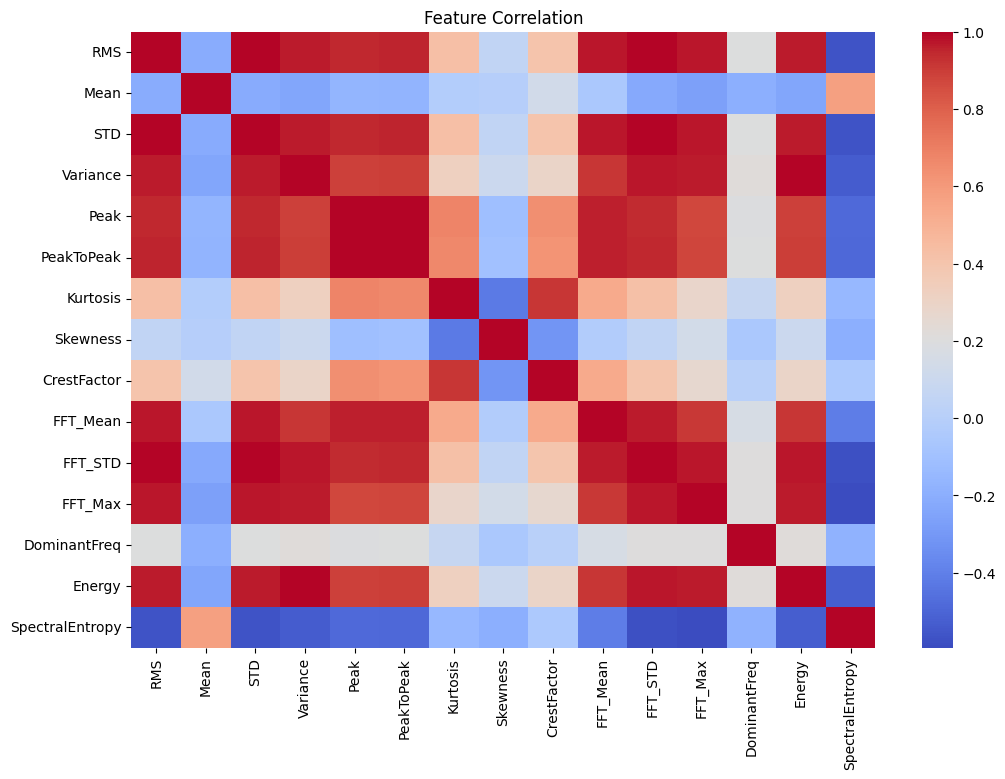

In [21]:

plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop('Fault',axis=1).corr(),
    cmap='coolwarm'
)

plt.title('Feature Correlation')
plt.show()


## 11. Train Test Split

In [22]:

X_train,X_test,y_train,y_test= train_test_split(
    df.drop('Fault',axis=1),
    df['Fault'],
    test_size=0.2,
    random_state=42,
    stratify=df['Fault']
)


## 12. Random Forest

In [23]:

rf=RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

rf_acc=accuracy_score(y_test,rf_pred)

print("RF Accuracy:",rf_acc)


RF Accuracy: 0.9662447257383966


## 13. SVM

In [24]:

svm=SVC(kernel='rbf')

svm.fit(X_train,y_train)

svm_pred=svm.predict(X_test)

svm_acc=accuracy_score(y_test,svm_pred)

print("SVM Accuracy:",svm_acc)


SVM Accuracy: 0.7447257383966245


## 14. Model Comparison

In [25]:

comparison=pd.DataFrame({
'Model':['Random Forest','SVM'],
'Accuracy':[rf_acc,svm_acc]
})

comparison


,Model,Accuracy
0,Random Forest,0.966245
1,SVM,0.744726


## 15. Confusion Matrix

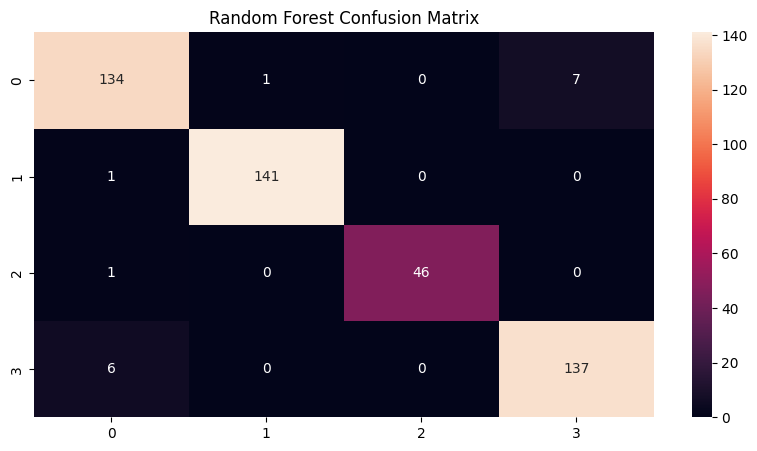

In [26]:

cm=confusion_matrix(y_test,rf_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.title('Random Forest Confusion Matrix')

plt.show()


## 16. Classification Report

In [27]:

print(
classification_report(
    y_test,
    rf_pred
)
)


              precision    recall  f1-score   support

  ball fault       0.94      0.94      0.94       142
  inner race       0.99      0.99      0.99       142
      normal       1.00      0.98      0.99        47
  outer race       0.95      0.96      0.95       143

    accuracy                           0.97       474
   macro avg       0.97      0.97      0.97       474
weighted avg       0.97      0.97      0.97       474



## 17. Feature Importance

In [28]:

importance=pd.DataFrame({
'Feature':features,
'Importance':rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)


,Feature,Importance
9,FFT_Mean,0.164707
5,PeakToPeak,0.107616
4,Peak,0.101883
0,RMS,0.080606
13,Energy,0.077584
3,Variance,0.067964
1,Mean,0.064122
10,FFT_STD,0.062092
12,DominantFreq,0.057191
14,SpectralEntropy,0.055615


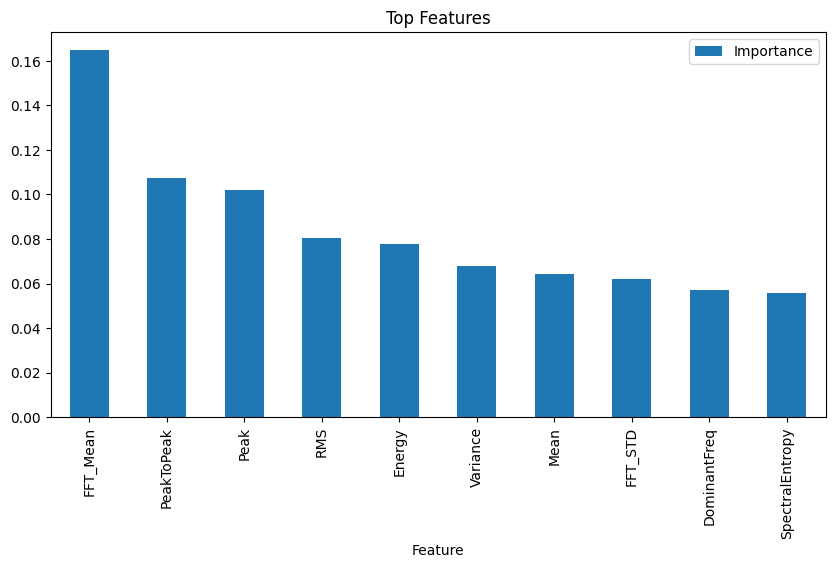

In [29]:

importance.head(10).plot(
x='Feature',
y='Importance',
kind='bar'
)

plt.title('Top Features')
plt.show()


## 18. Bearing Health Index

In [30]:

def health_index(prob):

    return round(
        np.max(prob)*100,
        2
    )

sample=X_test.iloc[[0]]

probs=rf.predict_proba(sample)

health=health_index(probs)

prediction=rf.predict(sample)[0]

print("Prediction:",prediction)
print("Health Index:",health,"%")


Prediction: normal
Health Index: 100.0 %


## 19. Maintenance Recommendation

In [38]:

if prediction == "normal":
    rec = "Bearing Healthy"
elif health > 90:
    rec = "Bearing Replacement Recommended — High Confidence Fault Detected"
else:
    rec = "Monitor During Next Maintenance Cycle — Uncertain Diagnosis"

print("Recommendation:",rec)


Recommendation: Bearing Healthy


## 20. Save Model

In [39]:

joblib.dump(
    rf,
    'bearing_fault_rf_model.pkl'
)

print("Model Saved")


Model Saved


In [42]:
from google.colab import files
files.download('bearing_fault_rf_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
from google.colab import files
uploaded = files.upload()

Saving sample.zip to sample.zip


In [7]:
import zipfile
with zipfile.ZipFile('sample.zip', 'r') as z:
    z.extractall('.')

In [8]:
!ls -la sample
!find sample -name "*.mat"

total 32
drwxr-xr-x 6 root root 4096 Jun 20 09:26  .
drwxr-xr-x 1 root root 4096 Jun 20 09:26  ..
drwxr-xr-x 2 root root 4096 Jun 20 09:26 'ball fault'
-rw-r--r-- 1 root root 6148 Jun 20 09:27  .DS_Store
drwxr-xr-x 2 root root 4096 Jun 20 09:26 'inner race'
drwxr-xr-x 2 root root 4096 Jun 20 09:26  normal
drwxr-xr-x 2 root root 4096 Jun 20 09:26 'outer race'
sample/normal/Time_Normal_1_098.mat
sample/inner race/IR021_1_214.mat
sample/inner race/IR014_1_175.mat
sample/inner race/IR007_1_110.mat
sample/outer race/OR007_6_1_136.mat
sample/outer race/OR014_6_1_202.mat
sample/outer race/OR021_6_1_239.mat
sample/ball fault/B014_1_190.mat
sample/ball fault/B021_1_227.mat
sample/ball fault/B007_1_123.mat
